# SetUp


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,mean_squared_error,log_loss
from tqdm import tqdm_notebook

from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import make_blobs

# Sigmoid Neuron Class with Loss function

In [3]:
class SigmoidNeuron:
    def __init__(self):
        self.w = None
        self.b = None
    
    def perceptron(self,x):
        return np.dot(x,self.w.T) + self.b
    
    def sigmoid(self,x):
        return np.where(x>=0,1.0/(1.0+np.exp(-x)),np.exp(x)/(1.0+np.exp(x)))
    def grad_w_mse(self,x,y):
        y_pred = self.sigmoid(self.perceptron(x))
        return (y_pred-y) * y_pred * (1-y_pred) * x
    def grad_b_mse(self,x,y):
        y_pred = self.sigmoid(self.perceptron(x))
        return (y_pred-y) * y_pred * (1-y_pred)
    def grad_w_ce(self,x,y):
        y_pred = self.sigmoid(self.perceptron(x))
        if y == 0 :
            return y_pred*x
        elif y == 1 :
            return -1 * (1-y_pred) * x
        else:
            raise ValueError("y should be 0 or 1")
    def grad_b_ce(self,x,y):
        y_pred = self.sigmoid(self.perceptron(x))
        if y == 0 :
            return y_pred
        elif y == 1 :
            return -1 * (1-y_pred) 
        else:
            raise ValueError("y should be 0 or 1")
        
    def fit(self,X,Y,epochs=1,learning_rate=1,initialise=True,loss_fn="mse",display_loss=False):
        # initialise w and b
        if initialise:
            self.w = np.random.randn(1,X.shape[1])
            self.b = 0
        if display_loss:
            loss={}
            
        for i in tqdm_notebook(range(epochs),total=epochs,unit="epoch"):
            dw = 0
            db = 0
            
            for x,y in zip(X,Y):
                if loss_fn == "mse":
                    dw += self.grad_w_mse(x,y)
                    db += self.grad_b_mse(x,y)
                elif loss_fn=='ce':
                    dw += self.grad_w_ce(x,y)
                    db += self.grad_b_ce(x,y)
            m = X.shape[1]
            self.w -= learning_rate * dw/m
            self.b -= learning_rate * db/m
            
            if display_loss:
                Y_pred = self.sigmoid(self.perceptron(X))
                if loss_fn=='mse':
                    loss[i]=mean_squared_error(Y,Y_pred)
                elif loss_fn=='ce':
                    loss[i] = log_loss(Y,Y_pred)   
        
        if display_loss:
            plt.plot(loss.values())
            plt.xlabel('Epochs')
            if loss_fn=="mse":
              plt.ylabel("Mean Squared Error")   
            elif loss_fn=='ce':
                plt.ylabel("Log loss")
            plt.show()
    def predict(self,X):
        Y_pred = []
        for x in X:
            y_pred = self.sigmoid(self.perceptron(x))
            Y_pred.append(y_pred)
        return np.array(Y_pred)              

In [4]:
my_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("",["red","yellow","green"])

# Generate Data

In [5]:
data , labels = make_blobs(n_samples=1000,centers=4,n_features=2,random_state=0)
print(data.shape,labels.shape)

(1000, 2) (1000,)


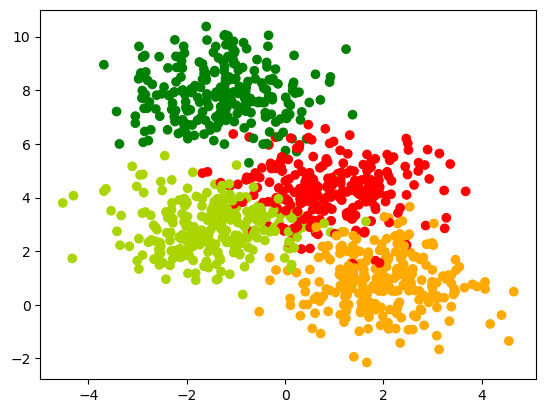

In [6]:
plt.scatter(data[:,0],data[:,1],c=labels,cmap=my_cmap)
plt.show()

In [7]:
labels_orig = labels
labels = np.mod(labels_orig,2)

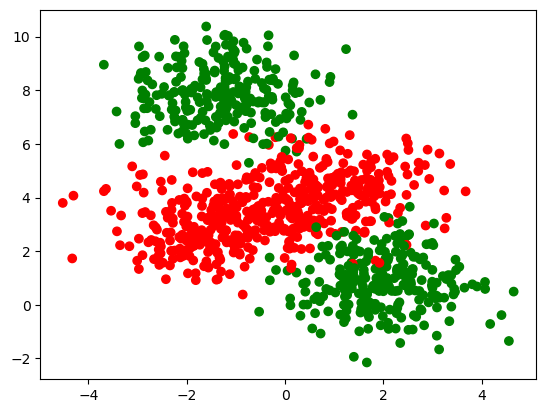

In [8]:
plt.scatter(data[:,0],data[:,1],c=labels,cmap=my_cmap)
plt.show()

In [9]:
X_train , X_val,Y_train,Y_val = train_test_split(data,labels,stratify=labels,random_state=0)
print(X_train.shape,X_val.shape)

(750, 2) (250, 2)


# SN classification

C:\Users\User\AppData\Local\Temp\ipykernel_25392\4038109648.py:42: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm_notebook(range(epochs),total=epochs,unit="epoch"):


  0%|          | 0/1000 [00:00<?, ?epoch/s]

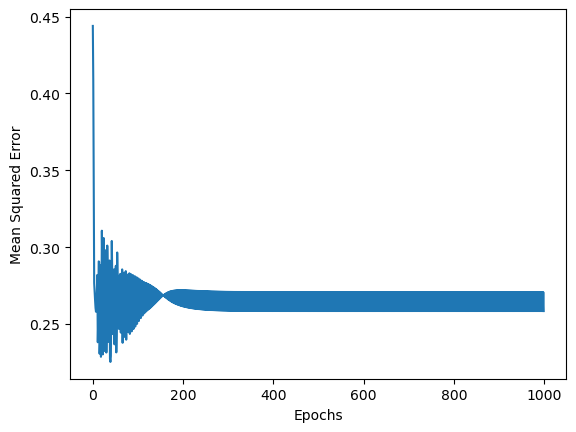

In [10]:
sn = SigmoidNeuron()
sn.fit(X_train,Y_train,epochs=1000,learning_rate=0.01,display_loss=True)

In [11]:
Y_pred_train = sn.predict(X_train)
Y_pred_binarised_train = (Y_pred_train>=0.5).astype("int").ravel()
Y_pred_val = sn.predict(X_val)
Y_pred_binarised_val = (Y_pred_val>=0.5).astype("int").ravel()
accuracy_train = accuracy_score(Y_pred_binarised_train,Y_train)
accuracy_val = accuracy_score(Y_pred_binarised_val,Y_val)

print("training accuracy ",round(accuracy_train,2))
print("Validation accuracy ",round(accuracy_val,2))

training accuracy  0.59
Validation accuracy  0.53


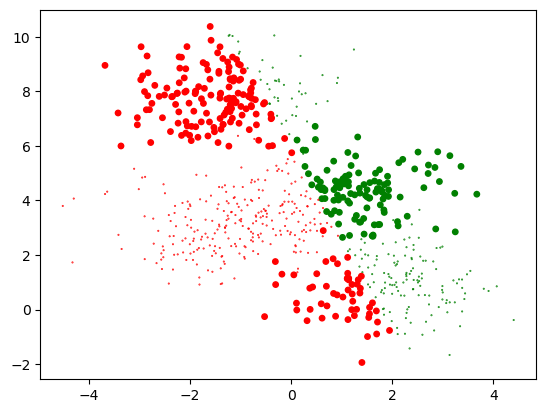

In [12]:
plt.scatter(X_train[:,0],X_train[:,1],c=Y_pred_binarised_train,cmap=my_cmap,s=15*(np.abs(Y_pred_binarised_train-Y_train))+.2)
plt.show()

# Feed Forward Network

In [13]:
class FFNetwork:
    def __init__(self) -> None:
        self.w1 = np.random.rand()
        self.w2 = np.random.rand()
        self.w3 = np.random.rand()
        self.w4 = np.random.rand()
        self.w5 = np.random.rand()
        self.w6 = np.random.rand()
        self.b1 = 0
        self.b2 = 0
        self.b3 = 0
    def sigmoid(self,x):
        return np.where(x>=0,1.0/(1.0+np.exp(-x)),np.exp(x)/(1.0+np.exp(x)))
    def forward_pass(self,x):
        self.x1 ,self.x2 = x 
        self.a1 = self.w1*self.x1+self.w2*self.x2+self.b1
        self.h1 = self.sigmoid(self.a1)
        self.a2 = self.w3*self.x1+self.w4 * self.x2 + self.b2
        self.h2 = self.sigmoid(self.a2)
        self.a3 = self.w5*self.h1+self.w6*self.h2+self.b3
        self.h3=self.sigmoid(self.a3)
        return self.h3
    def grad(self,x,y):
        self.forward_pass(x)
        
        self.dw5 = (self.h3-y) * self.h3*(1-self.h3) * self.h1
        self.dw6 = (self.h3-y) * self.h3*(1-self.h3) * self.h2
        self.db3 = (self.h3-y) * self.h3*(1-self.h3)
        
        self.dw1 = (self.h3-y) * self.h3*(1-self.h3) * self.w5 *self.h1*(1-self.h1) * self.x1
        self.dw2 = (self.h3-y) * self.h3*(1-self.h3) * self.w5 *self.h1*(1-self.h1) * self.x2
        self.db1 = (self.h3-y) * self.h3*(1-self.h3) * self.w5 *self.h1*(1-self.h1)
        
        self.dw3 = (self.h3-y) * self.h3*(1-self.h3) * self.w6 *self.h2*(1-self.h2) * self.x1
        self.dw4 = (self.h3-y) * self.h3*(1-self.h3) * self.w6 *self.h2*(1-self.h2) * self.x2
        self.db2 = (self.h3-y) * self.h3*(1-self.h3) * self.w6 *self.h2*(1-self.h2)
        
    def fit(self,X,Y,epochs=1,learning_rate=1.0,initialise=True,display__loss=False):
        
        if initialise:
            np.random.seed(0)
            self.w1 = np.random.rand()
            self.w2 = np.random.rand()
            self.w3 = np.random.rand()
            self.w4 = np.random.rand()
            self.w5 = np.random.rand()
            self.w6 = np.random.rand()
            self.b1 = 0
            self.b2 = 0
            self.b3 = 0
        
        if display__loss:
            loss={}
        
        for i in tqdm_notebook(range(epochs),total=epochs,unit='epoch'):
            dw1,dw2,dw3,dw4,dw5,dw6,db1,db2,db3 = [0]*9
            for x,y in zip(X,Y):
                self.grad(x,y)
                dw1 += self.dw1
                dw2 += self.dw2
                dw3 += self.dw3
                dw4 += self.dw4
                dw5 += self.dw5
                dw6 += self.dw6
                db1 += self.db1
                db2 += self.db2
                db3 += self.db3
            m = X.shape[0]
            self.w1 -= learning_rate*dw1/m
            self.w2 -= learning_rate*dw2/m
            self.w3 -= learning_rate*dw3/m
            self.w4 -= learning_rate*dw4/m
            self.w5 -= learning_rate*dw5/m
            self.w6 -= learning_rate*dw6/m
            self.b1 -= learning_rate*db1/m
            self.b2 -= learning_rate*db2/m
            self.b3 -= learning_rate*db3/m
            
            if display__loss:
                Y_pred = self.predict(X)
                loss[i] = mean_squared_error(Y_pred,Y)
        if display__loss:

            plt.plot(loss.values())
            plt.xlabel("epochs")
            plt.ylabel("Mean Squared Error")
            
            plt.show()
    
    def predict(self,X):
        Y_pred = []
        for x in X:
            y_pred = self.forward_pass(x)
            Y_pred.append(y_pred)
        return np.array(Y_pred)
    
    def predict_h1(self,X,binary=True):
        Y_pred = []
        for x in X:
            y_pred = self.forward_pass(x)
            Y_pred.append(self.h1)
        return np.array(Y_pred)
    def predict_h2(self,X,binary=True):
        Y_pred = []
        for x in X:
            y_pred = self.forward_pass(x)
            Y_pred.append(self.h2)
        return np.array(Y_pred)
    def predict_h3(self,X,binary=True):
        Y_pred = []
        for x in X:
            y_pred = self.forward_pass(x)
            Y_pred.append(self.h3)
        return np.array(Y_pred)

C:\Users\User\AppData\Local\Temp\ipykernel_25392\4058420782.py:55: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm_notebook(range(epochs),total=epochs,unit='epoch'):


  0%|          | 0/2000 [00:00<?, ?epoch/s]

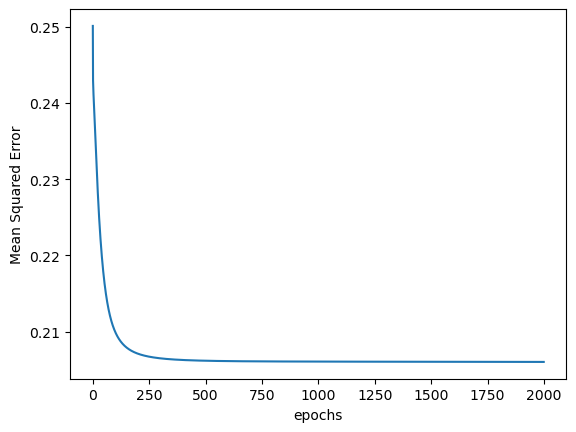

In [14]:
ffnw1 = FFNetwork()
ffnw1.fit(X_train,Y_train,epochs=2000,learning_rate=5,display__loss=True)

In [15]:
Y_pred_train = ffnw1.predict(X_train)
Y_pred_binarised_train = (Y_pred_train>=0.5).astype("int").ravel()
Y_pred_val = sn.predict(X_val)
Y_pred_binarised_val = (Y_pred_val>=0.5).astype("int").ravel()
accuracy_train = accuracy_score(Y_pred_binarised_train,Y_train)
accuracy_val = accuracy_score(Y_pred_binarised_val,Y_val)

print("training accuracy ",round(accuracy_train,2))
print("Validation accuracy ",round(accuracy_val,2))

training accuracy  0.67
Validation accuracy  0.53


# Generic Feed Forward Class


In [ ]:
class FFSNNetwork:
    
    def __init__(self,n_inputs,hidden_sizes=[2]):
        self.nx = n_inputs
        self.ny = 1
        self.nh = len(hidden_sizes)
        self.sizes = [self.nx] + hidden_sizes + [self.ny]
        
        self.W = {}
        self.B = {}
        
        for i in range(self.nh+1):
            self.W[i+1] = np.random.randn(self.sizes[i],self.sizes[i+1])
            self.B[i+1] = np.zeros(1,self.sizes[i+1])
        
    def sigmoid(self,x):
        return np.where(x>=0,1.0/(1.0+np.exp(-x)),np.exp(x)/(1.0+np.exp(x)))
    def forward_pass(self,X):
        self.A = {}
        self.H = {}
        self.H[0] = X.reshape(1,-1)
        for i in range(self.nh+1):
            self.A[i+1] = np.matmul()